# Run ABC on LG analogues

This notebook runs the `lg_analogues` pipeline and then applies simple rejection + kernel ABC.
All posterior summaries are conditional on the selection/cuts `S` used here.


In [10]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

# Ensure we import from /scripts (not notebooks/lg_analogues.py)
repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / "scripts"))
sys.path.insert(0, str(repo_root / "illustris_python"))

import lg_analogues as lg
from lg_abc import (
    build_pair_catalog,
    make_feature_matrix,
    make_theta_vector,
    abc_distance_diagonal,
    abc_rejection_mask,
    abc_kernel_weights,
    summarize_posterior,
    effective_sample_size,
    run_abc_catalog,
)


print("lg_analogues:", lg.__file__)


lg_analogues: /home/tp/Documents/uni/dsp/scripts/lg_analogues.py


## 1) Load simulation data and constants
We load only the fields needed for this analysis to keep memory usage lower.
`h` and `box_ckpch` are required for correct distance conversions and periodic pair finding.

In [2]:
# Data paths and fields
basePath = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
snap = 99

subhalo_fields = [
    "SubhaloPos",
    "SubhaloVel",
    "SubhaloMassType",
    "SubhaloSFRinRad",
    "SubhaloFlag",
    "SubhaloGrNr",
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
header_consts = lg.load_header_constants(basePath, snap)
h = header_consts["h"]
box_ckpch = header_consts["box_ckpch"]

print("Loaded subhalos:", sub["count"])
print("h:", h, "box_ckpch:", box_ckpch)


Loaded subhalos: 14485709
h: 0.6774 box_ckpch: 205000.0


## 2) Define the selection S (this is the **prior** for ABC)

Before ABC even starts, we decide what counts as a *candidate* Local Group (LG) analogue in the simulation.
Call this whole decision process **S**.

In classic Bayesian terms, once you apply `S` you are no longer working with an unconditional cosmological prior.
You are working with **the distribution of simulated systems that survive S**.

In this notebook, `S` includes:

- **Object-level selection inside FoF groups**: keep the central plus the most massive satellite in each FoF group.
  This is motivated by the fact that focusing only on centrals can miss plausible MW–M31 configurations, and including
  central–satellite pairs increases sample size. (See project notes about moving beyond “only central halos”.)
- **A stellar-mass window**: `mstar_min <= M* <= mstar_max`.
  The meeting notes suggest raising the minimum stellar mass to something like `2 × 10^10 Msun`, which is what we use.
- **Pair-level cuts later**: separation window and isolation criteria.

Everything you infer with ABC later should be read as:

> posterior **conditional on** the selection/cuts `S`

If `S` is too strict or mismatched to the real Local Group, no amount of ABC tuning can fix that.


In [3]:
# Selection S: central + largest satellite in stellar-mass window
mstar_min = 2e10
mstar_max = 5e11

sample = lg.select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=mstar_min,
    mstar_max=mstar_max,
)

print("Selected objects:", sample.keep_idx.size)


Selected objects: 45392


## 3) Build candidate pairs
We find pairs in a physically motivated separation window.
This defines the candidate set before environmental filtering.

In [ ]:
# Pair finding in separation window
r_min_kpc = 500.0
r_max_kpc = 1000.0

pair_set = lg.find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,# Pair finding in separation window
r_min_kpc = 500.0
r_max_kpc = 1000.0

pair_set = lg.find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box_ckpch,
    r_min_kpc=r_min_kpc,
    r_max_kpc=r_max_kpc,
)

print("Pairs before filtering:", pair_set.i.size)
print("same-host pairs:", int(np.sum(pair_set.same_host)))
print("different-host pairs:", int(np.sum(~pair_set.same_host)))

    box_ckpch=box_ckpch,
    r_min_kpc=r_min_kpc,
    r_max_kpc=r_max_kpc,
)

print("Pairs before filtering:", pair_set.i.size)
print("same-host pairs:", int(np.sum(pair_set.same_host)))
print("different-host pairs:", int(np.sum(~pair_set.same_host)))


Pairs before filtering: 2655
same-host pairs: 2084
different-host pairs: 571


## 4) Apply pipeline filters and inspect cutflow

At this stage we have a *candidate pair list* based only on separation.

Now we apply additional **environmental / isolation** filters, because the real Local Group is not in a rich group/cluster.
In the meeting notes, one suggested isolation criterion is:

> there is no other (third) subhalo in the relevant environment that is a factor `x` more massive than the pair members

The function we use here implements the simple "no third object above a mass threshold in the same group" idea.
We track the cutflow through `AnaloguePipeline`, so later plots can reproduce exactly which pairs were removed at each step.


In [5]:
# Pipeline filters: isolation (no third object with M* >= x * max(M*_pair) in relevant FoF group(s))
pipeline = lg.AnaloguePipeline(pair_set)

isolation_x = 1.5
iso_mask = lg.isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pair_i=pipeline.pairs.i,
    pair_j=pipeline.pairs.j,
    sample_grnr=sample.grnr,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    x=isolation_x,
)
pipeline.apply_filter(f"isolation_x{isolation_x}", iso_mask)

pipeline.print_cutflow()
cutflow = pipeline.get_cutflow()
cutflow


initial: 2655 pairs remaining
isolation_x1.5: 2601 pairs remaining


[{'label': 'initial', 'before': 2655, 'after': 2655, 'frac_kept': 1.0},
 {'label': 'isolation_x1.5',
  'before': 2655,
  'after': 2601,
  'frac_kept': 0.9796610169491525}]

## 5) Prepare ABC inputs (connect this to the coin tutorial)

In the coin-flip ABC tutorial, the objects are:

- **θ (parameter)**: coin bias `p`
- **simulate data**: `k_sim ~ Binomial(n, p)`
- **observed data**: `k_obs`
- **distance**: `|k_sim - k_obs|`
- **accept**: `distance <= eps`

In the LG analogue setting we are doing the same pattern, but the "simulator" is an existing simulation catalogue:

- **θ (target to infer)**: some property of the LG we cannot measure directly.
  In this notebook we start with: `theta = log10(mdm_sum)` where `mdm_sum = mdm_i + mdm_j`.
- **x (observables-like summaries)**: things we *can* compare to the observed Local Group.
  Here we start with: `x = [r_kpc, v_r, v_t]`.
- **x_obs (observed target)**: best-estimate observed LG values in the same units/definitions as `x`.
- **sigma (scales / uncertainties)**: how strict the matching should be in each feature.
- **distance**: a weighted Euclidean distance in feature space:
  `d_i = sqrt(sum(((x_i - x_obs)/sigma)^2))`.

Two ABC variants are shown:

- **Rejection ABC**: keep the closest analogues (by `eps`, by fraction, or by fixed count)
- **Kernel ABC**: weight all analogues by a Gaussian kernel in distance

The output is an approximation to `p(theta | x_obs, S)`, where `S` is the selection/cuts defined earlier.


## 5a) What ABC is doing *in this specific project*

By the time we reach ABC, we already have a finite list of simulated systems:

- each **row i** = one simulated LG analogue pair that survived selection `S`
- each row comes with:
  - `x_i` = observables-like summaries (separation, velocities, masses, ...)
  - `theta_i` = target properties (e.g. total halo mass, energy, angular momentum proxies, ...)

### Classic ABC vs catalogue-ABC

**Classic ABC (textbook)**
1. Draw `theta ~ prior`
2. Simulate `x_sim ~ p(x | theta)`
3. Accept or weight based on `distance(x_sim, x_obs)`

**This notebook (catalogue-ABC)**
We *skip steps 1–2* because the simulation already gave us many draws from the prior and their implied observables.
So ABC becomes a *re-weighting* of existing rows:

- compute `d_i = distance(x_i, x_obs)`
- define either:
  - rejection mask `acc_i` (hard cut), or
  - kernel weights `w_i` (soft cut)

Then the posterior is approximated by a discrete distribution over rows:

- rejection ABC: `p(theta | x_obs, S) ≈ { theta_i : acc_i = True }`
- kernel ABC: `p(theta | x_obs, S) ≈ Σ_i w_i δ(theta - theta_i)`

This is why **cutflow and sample size** matter so much:
if selection `S` leaves only a small/biased catalogue, the posterior is small/biased too.

### The distance used here

We use a diagonal-covariance (feature-wise scaled) distance:

`d_i = sqrt( Σ_j ((X_ij - x_obs_j) / sigma_j)^2 )`

Interpretation:
- `sigma_j` is the tolerance scale for feature `j`
- large `sigma` -> loose matching -> posterior close to the unconditional distribution
- small `sigma` -> strict matching -> very few accepted / very small ESS

The `x_obs` and `sigma` values in this notebook are placeholders for exploration.
Replace them with values and uncertainty scales the project agrees on.


## 5b) How to choose `x_obs` and `sigma` (practical guidance)

1. **Make sure the definitions match.**
   - If `r_kpc` in the simulation is a 3D separation, use a 3D observed separation (or treat it as an approximation).
   - If `v_r` and `v_t` are defined in the pair center-of-mass frame, be consistent when defining observed values.

2. **Start with published LG kinematics, then inflate tolerances if needed.**
   A common reference point from HST proper-motion work reports (Milky Way–M31):
   - separation: ~770 kpc
   - radial approach velocity: ~ -109 km/s (negative = approaching)
   - tangential velocity: of order tens of km/s (consistent with a small value, but with uncertainty)

   These are ballpark numbers; for ABC, the exact values matter less than choosing
   `sigma` that reflects both measurement uncertainty and "model mismatch" between simulation and reality.

3. **Choose `sigma` as (measurement uncertainty) + (model tolerance).**
   Even if an observed quantity has a small formal uncertainty, you often need a larger `sigma`
   to avoid acceptance collapsing to almost nothing in 3D feature space.
   A simple workflow:
   - pick `sigma` equal to measurement errors
   - check acceptance count / ESS
   - multiply `sigma` by 2–5 until the posterior is stable and not dominated by a handful of analogues

4. **Dimensionality bites quickly.**
   Every extra feature shrinks acceptance (roughly exponentially) unless `sigma` is loosened.
   Start with 1–2 features and add more only once the pipeline is working.

Tip: if you want a fixed number of accepted samples (like in the coin notebook),
you can accept the closest `N` rows instead of an `eps` threshold.


In [6]:
# Build per-pair catalog and ABC inputs
cat = build_pair_catalog(
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub,
    sfr_field="SubhaloSFRinRad",
)

# Choose the feature vector x = (x1, x2, ...)
# Start small (1-2 features), then add more
features = ["r_kpc", "v_r", "v_t"]
X, Xmeta = make_feature_matrix(cat, features, standardize=False)

# Choose the target theta to infer (posterior)
# Here: log10(total DM mass of the pair)
theta = make_theta_vector(cat, "mdm_sum", log10=True)

# Observational target and tolerance scales (placeholders for exploration)
x_obs = np.array([770.0, -109.0, 17.0], dtype=float)
sigma = np.array([50.0, 20.0, 30.0], dtype=float)

# ABC tuning knobs:
# - accept_frac: keep the closest fraction of analogues
# - accept_n: keep the closest fixed count (coin-tutorial style)
accept_frac = 0.05
accept_n = None

results = run_abc_catalog(
    X,
    theta,
    x_obs=x_obs,
    sigma=sigma,
    accept_frac=accept_frac,
    accept_n=accept_n,
    kernel_bandwidth=1.0,
)

d = results["d"]
acc = results["accept_mask"]
w = results["weights"]
theta_acc = results["theta_accepted"]

print("Pairs after cuts:", theta.size)
print("Accepted (rejection):", int(acc.sum()), "/", acc.size, "accept_rate =", results["accept_rate"])
print("Rejection posterior:", results["summary_rejection"])
print("Kernel posterior:", results["summary_kernel"])
print("Kernel ESS:", results["ess"])

Pairs after cuts: 2601
Accepted (rejection): 131 / 2601 accept_rate = 0.050365244136870435
Rejection posterior: {'mean': 12.558323849044358, 'median': 12.504323511880862, 'q16': 12.37038867567865, 'q84': 12.640507890143033}
Kernel posterior: {'mean': 12.520913276048553, 'median': 12.472528060017112, 'q16': 12.369241135213237, 'q84': 12.609286523989482, 'ess': 55.29047533914513}
Kernel ESS: 55.29047533914513


### How to read the ABC printouts

After running the code cell below, focus on:

- **Pairs after cuts**: how many analogues remain after selection `S`.
- **Accepted (rejection)**: how many are retained by rejection ABC for the chosen acceptance rule.
  - Very small acceptance (e.g., < 10) usually means the constraint set is too strict or too high-dimensional.
- **Kernel ESS** (effective sample size):
  - `ESS = 1 / sum(w^2)` when weights are normalized.
  - ESS near 1 means the posterior is dominated by a single analogue (too strict).
  - ESS closer to the number of pairs means weights are nearly uniform (too loose).

Practical workflow:
1. Start with fewer features (e.g., `["r_kpc", "v_r"]`).
2. Tune `sigma` until ESS is comfortably large.
3. Add features (e.g., `v_t`, then masses) and re-tune.
4. Check stability: does the posterior change a lot if you vary `accept_frac` or `sigma` slightly?


## 6) Visual diagnostics
We check:
- whether selected-pair features look reasonable
- whether rejection and kernel posteriors are sensible
- where low-distance analogues sit in feature space

If acceptance is too small/large, tune `features`, `x_obs`, `sigma`, and `accept_frac`.

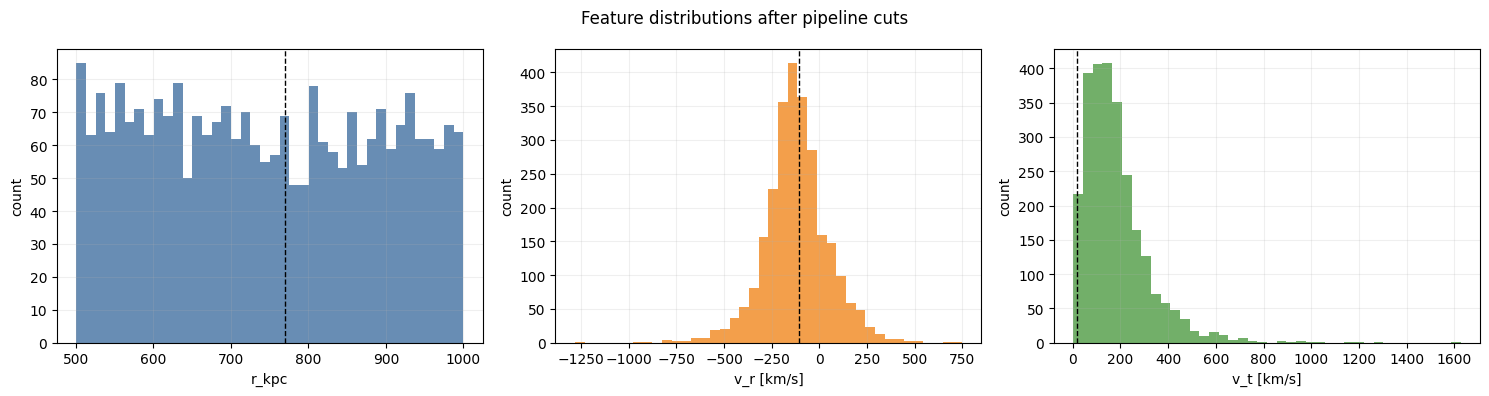

In [7]:
# Quick-look plots
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(cat["r_kpc"], bins=40, color="#4e79a7", alpha=0.85)
ax[0].axvline(x_obs[0], color="k", ls="--", lw=1)
ax[0].set_xlabel("r_kpc")

ax[1].hist(cat["v_r"], bins=40, color="#f28e2b", alpha=0.85)
ax[1].axvline(x_obs[1], color="k", ls="--", lw=1)
ax[1].set_xlabel("v_r [km/s]")

ax[2].hist(cat["v_t"], bins=40, color="#59a14f", alpha=0.85)
ax[2].axvline(x_obs[2], color="k", ls="--", lw=1)
ax[2].set_xlabel("v_t [km/s]")

for a in ax:
    a.set_ylabel("count")
    a.grid(alpha=0.2)

fig.suptitle("Feature distributions after pipeline cuts")
plt.tight_layout()
plt.show()


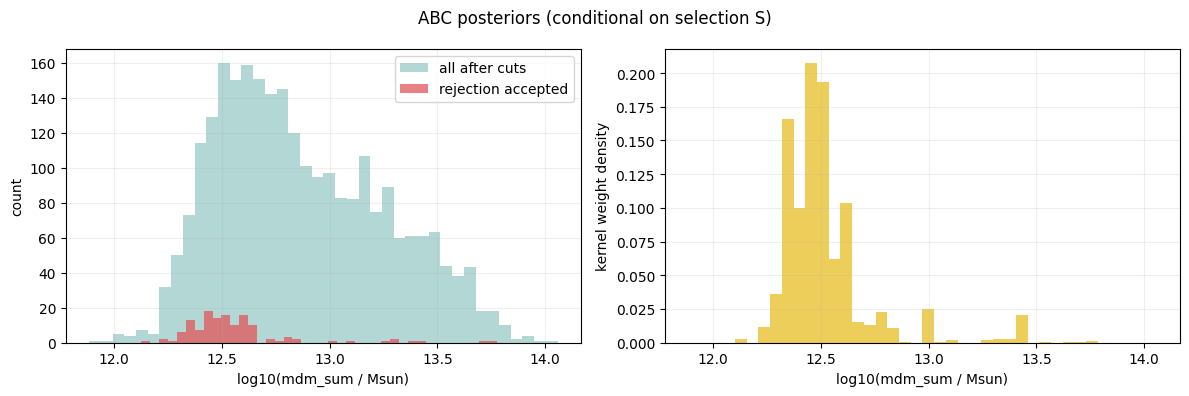

In [8]:
# Posterior visualization for theta = log10(mdm_sum)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(theta, bins=40, alpha=0.55, label="all after cuts", color="#76b7b2")
if theta_acc.size > 0:
    ax[0].hist(theta_acc, bins=40, alpha=0.75, label="rejection accepted", color="#e15759")
ax[0].set_xlabel("log10(mdm_sum / Msun)")
ax[0].set_ylabel("count")
ax[0].legend()
ax[0].grid(alpha=0.2)

ax[1].hist(theta, bins=40, weights=w, alpha=0.9, color="#edc948")
ax[1].set_xlabel("log10(mdm_sum / Msun)")
ax[1].set_ylabel("kernel weight density")
ax[1].grid(alpha=0.2)

fig.suptitle("ABC posteriors (conditional on selection S)")
plt.tight_layout()
plt.show()


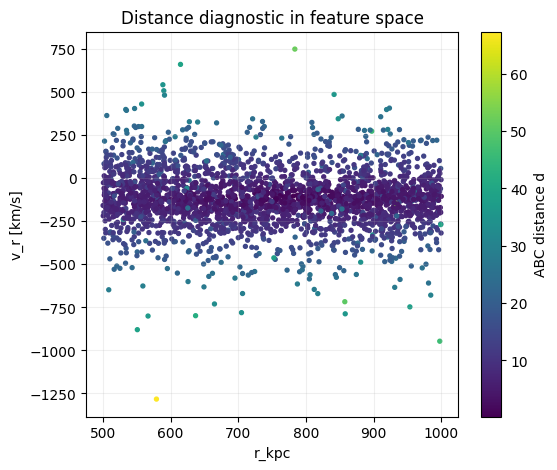

In [9]:
# Distance diagnostic: lower distance = closer to x_obs
plt.figure(figsize=(6, 5))
sc = plt.scatter(cat["r_kpc"], cat["v_r"], c=d, s=8, cmap="viridis")
plt.colorbar(sc, label="ABC distance d")
plt.xlabel("r_kpc")
plt.ylabel("v_r [km/s]")
plt.title("Distance diagnostic in feature space")
plt.grid(alpha=0.2)
plt.show()
